In [1]:
import torch
import torch.nn.functional as F

from torch import nn
from stable_baselines3 import A2C, DDPG, PPO, SAC, TD3
from src.eval import visualize_simulation, evaluate_pricing_agent
from src.callback import env_callback

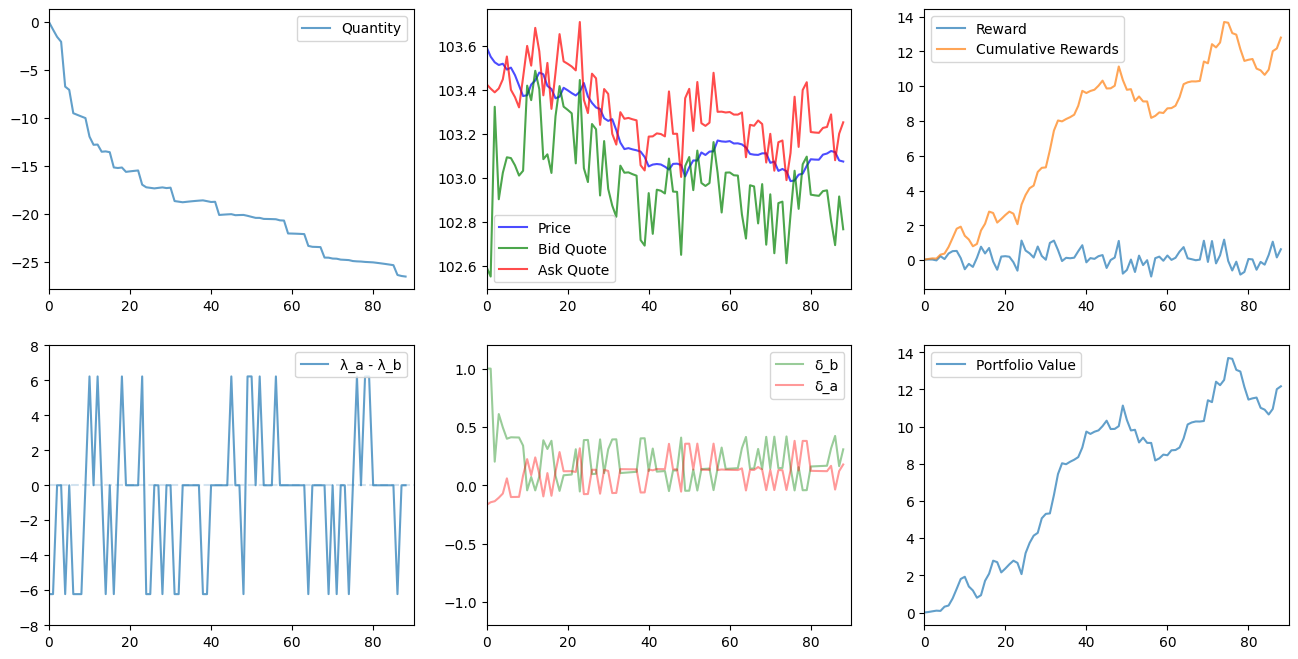

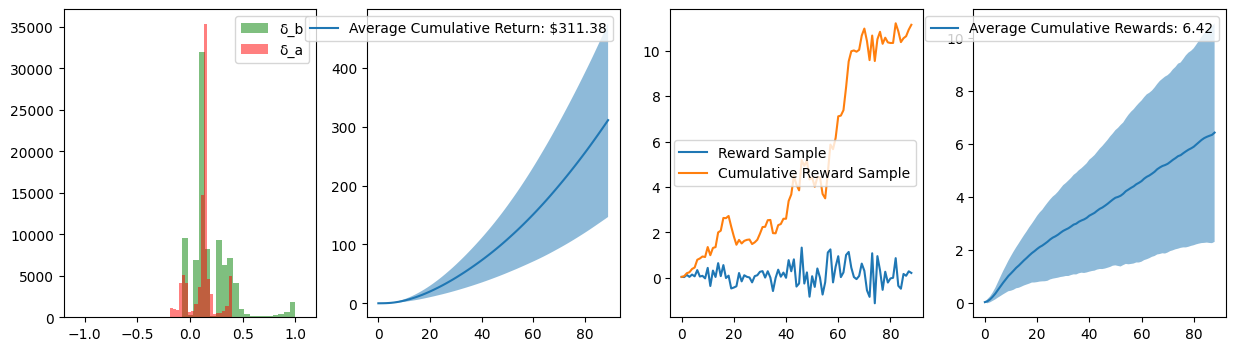

In [2]:
model = PPO.load("models/optimal/PPO")

visualize_simulation(env_callback(), model, sleep=0.01)
evaluate_pricing_agent(env_callback(), model, clear=False, n=1000)

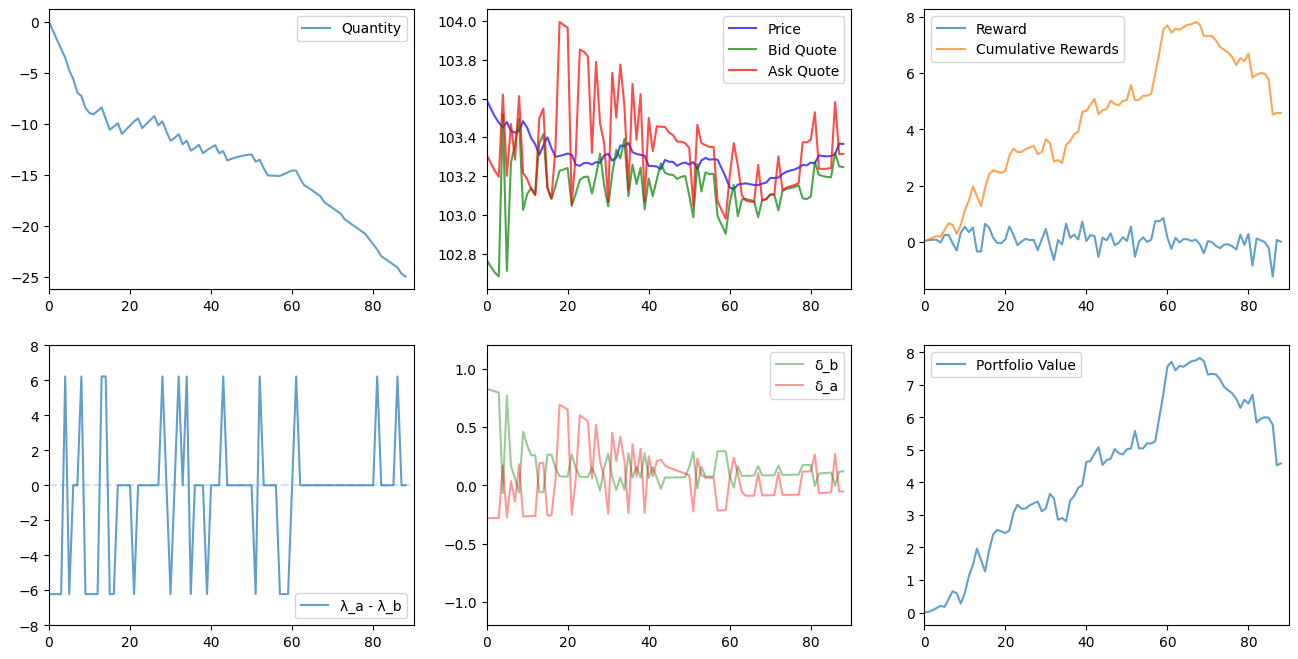

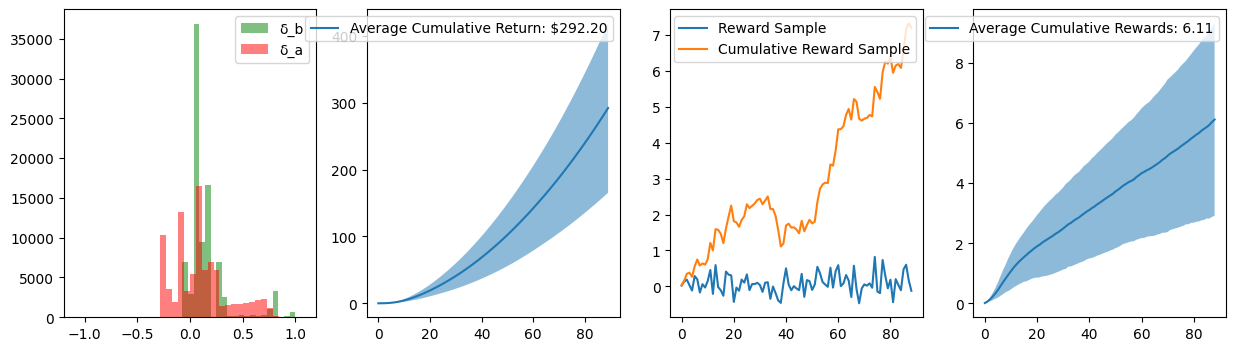

In [3]:
model = DDPG.load("models/optimal/DDPG")

visualize_simulation(env_callback(), model, sleep=0.01)
evaluate_pricing_agent(env_callback(), model, clear=False, n=1000)

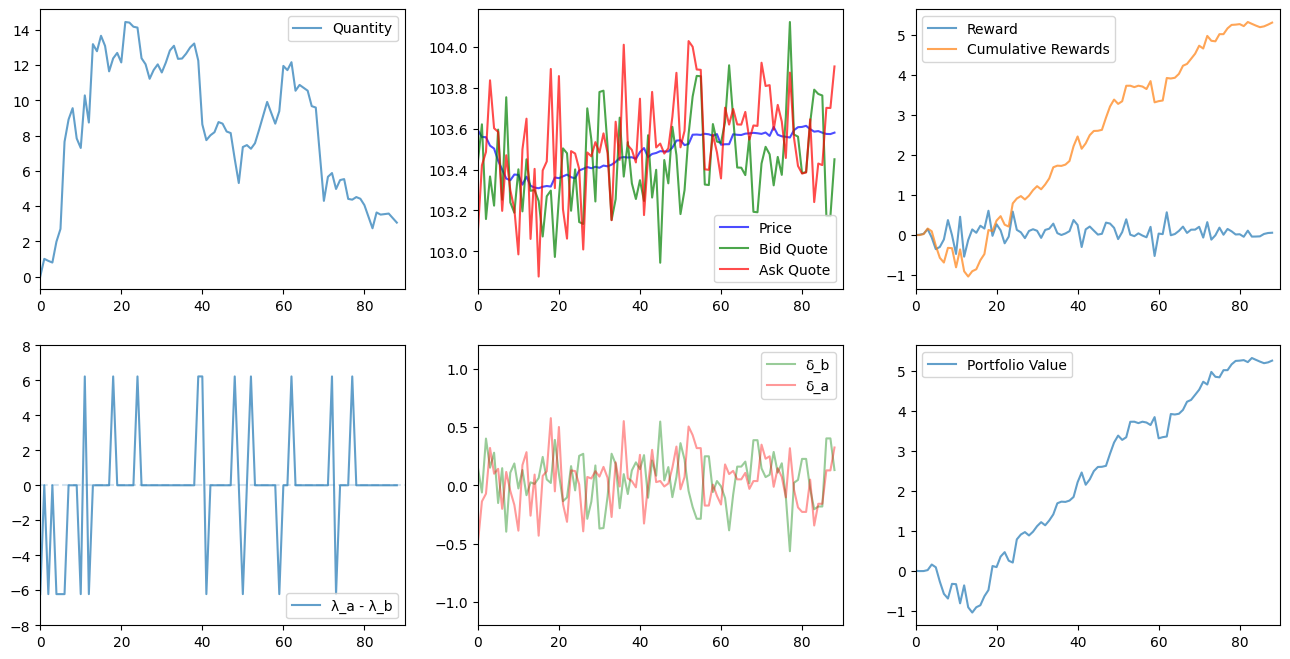

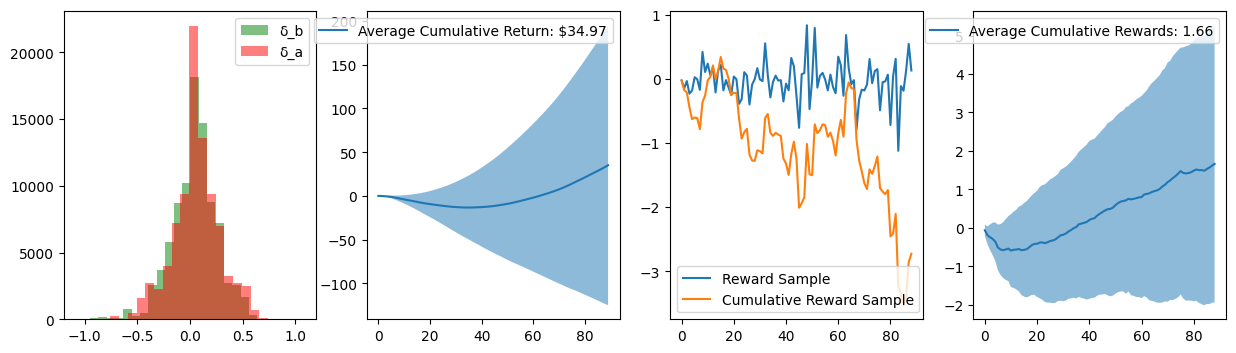

In [4]:
class RL_Net(nn.Module):
    def __init__(self, INPUT_DIM, OUTPUT_DIM, HIDDEN_DIM, First=False):
        super(RL_Net, self).__init__()
        self.input_dim = INPUT_DIM
        self.output_dim = OUTPUT_DIM
        self.hidden_dim = HIDDEN_DIM
        self.is_first = First
        current_dim = self.input_dim
        self.layers = nn.ModuleList()
        self.bn = nn.ModuleList()
        self.droupout = nn.ModuleList()  # drop out layer for regularization
        for hdim in self.hidden_dim:
            self.layers.append(nn.Linear(int(current_dim), int(hdim)))
            self.bn.append(nn.BatchNorm1d(int(hdim)))
            self.droupout.append(nn.Dropout(0.25))  # add a dropout layer
            current_dim = hdim
        self.layers.append(nn.Linear(int(current_dim), int(self.output_dim)))

    def forward(self, x):
        for i, layer in enumerate(self.layers[:-1]):
            x = layer(x)
            if self.is_first == False:
                x = self.bn[i](x)
            x = F.tanh(x)
        out = self.layers[-1](x)
        return out


class DeepSOCModel:
    def __init__(self) -> None:
        self.env = env_callback()
        self.q_next = 0
        self.bid_models = []

        for i in range(90):
            bid_model = RL_Net(4, 1, [10, 10, 20, 10])
            bid_model.load_state_dict(torch.load(f"models/deepSOC/bid-{i}"))
            bid_model.eval()
            self.bid_models.append(bid_model)

        self.ask_models = []

        for i in range(90):
            ask_model = RL_Net(4, 1, [10, 10, 20, 10])
            ask_model.load_state_dict(torch.load(f"models/deepSOC/ask-{i}"))
            ask_model.eval()
            self.ask_models.append(ask_model)

    def predict(self, state, deterministic=False):
        λ_b, λ_a, _, t = state

        model_index = int(self.env.rfq_price_sampler.num_time_interval * t)

        t = model_index * 0.25 / self.env.rfq_price_sampler.num_time_interval

        model_input = torch.tensor(
            [t, self.q_next, λ_a, λ_b], dtype=torch.float32
        ).reshape(1, -1)

        self.q_next = λ_b - λ_a

        δ_b = self.bid_models[model_index](model_input).detach().numpy()[0][0]
        δ_a = self.ask_models[model_index](model_input).detach().numpy()[0][0]

        return [δ_b, δ_a], None


deep_soc_model = DeepSOCModel()
visualize_simulation(env_callback(), deep_soc_model, sleep=0.01)
evaluate_pricing_agent(env_callback(), deep_soc_model, clear=False, n=1000)

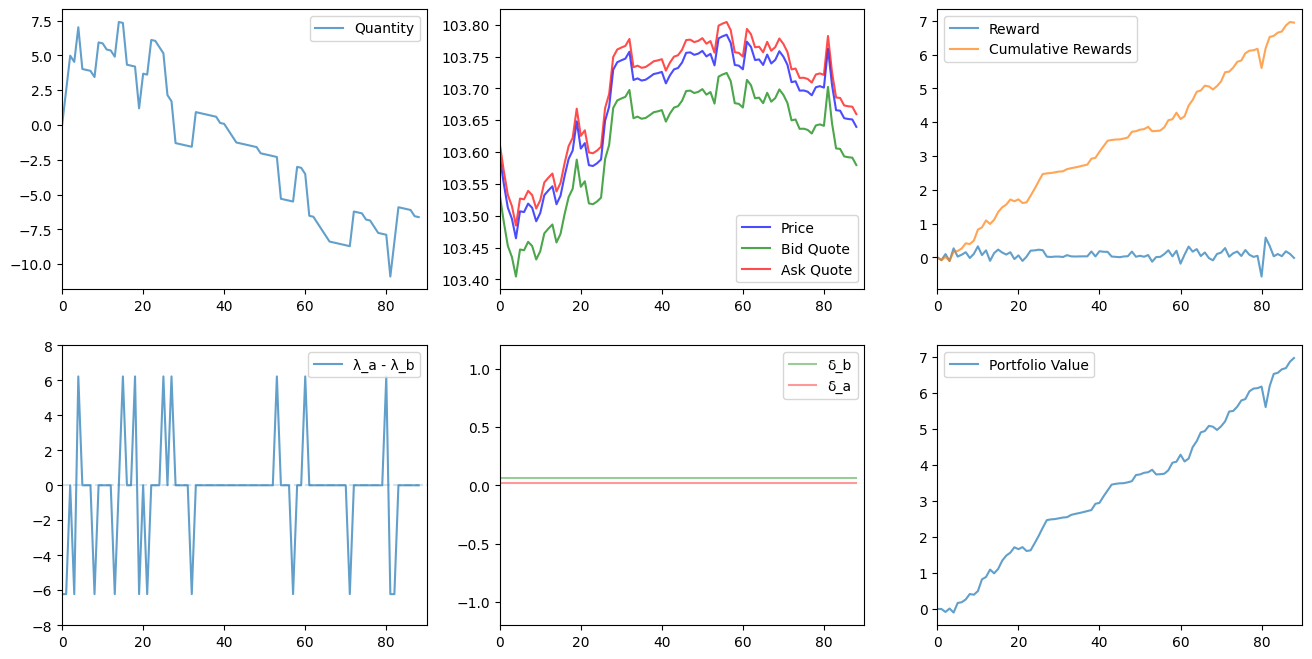

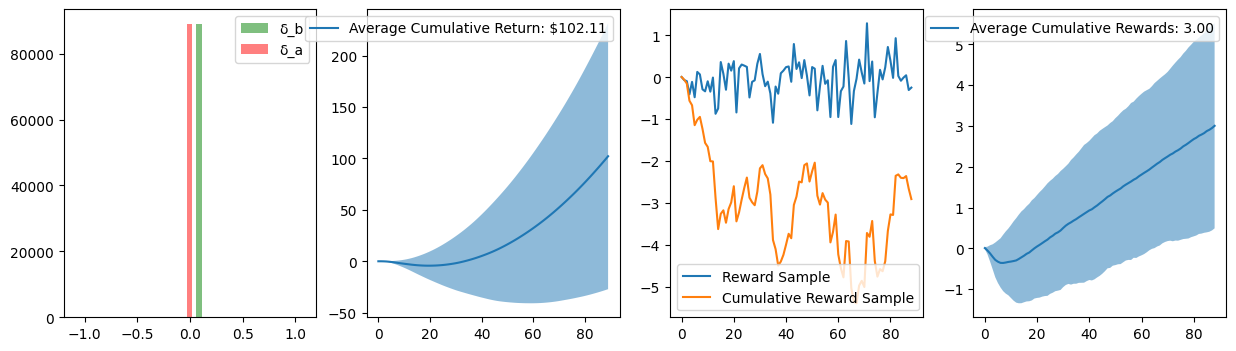

In [5]:
class FixedModel:
    def predict(self, _, deterministic=True):
        return [0.06, 0.02], None


visualize_simulation(env_callback(), FixedModel(), sleep=0.01)
evaluate_pricing_agent(env_callback(), FixedModel(), clear=False, n=1000)